In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [40]:
# Load the dataset
df = pd.read_csv('results/experiment_runs_log_users_actions_changes_only.csv')
df_experiment_details = pd.read_csv("results/experiment_runs_log_users_info_P7iwzVBKHYbSDrUWE.csv", header=0, usecols=range(12))

# Analyze correct answers for payment

In [41]:
def xai_helped(pred, true, before_ai, after_ai, after_xai):
    # return after_ai != true and after_xai == true and pred == true
    return after_ai != true and after_xai == true

def xai_harmed(pred, true, before_ai, after_ai, after_xai):
    # return after_ai == true and after_xai != true and pred == true
    return after_ai == true and after_xai != true 

def xai_no_influence(pred, true, before_ai, after_ai, after_xai):
    return (after_ai == true and after_xai == true) or (after_ai != true and after_xai != true) or (after_ai == after_xai)

def ai_helped(pred, true, before_ai, after_ai, after_xai):
    # return before_ai != true and after_ai == true and pred == true
    return before_ai != true and after_ai == true

def ai_harmed(pred, true, before_ai, after_ai, after_xai):
    # return before_ai == true and after_ai != true and pred != true
    return before_ai == true and after_ai != true

def ai_no_influence(pred, true, before_ai, after_ai, after_xai):
    return (before_ai != true and after_ai != true) or (before_ai==true and after_ai==true)

In [42]:
def convert_2_int(num):
    if pd.isna(num) or num == '-':
        return None
    return int(num)

def analysis_test_results(users, users_logs):
    users_test_results = {}

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]

        correct_count = 0
        ai_helped_count = 0
        ai_harmed_count = 0
        ai_no_influence_count = 0

        xai_helped_count = 0
        xai_harmed_count = 0
        xai_no_influence_count = 0
        
        questions_num = 0

        correct_before_ai = {
         'LLM': 0,
          'OS': 0
        }
        correct_after_ai = {
         'LLM': 0,
          'OS': 0
        }
        correct_after_xai = {
         'LLM': 0,
          'OS': 0
        }
        questions_3_stages = {
         'correct_pred_OS': 0,
         'incorrect_pred_OS': 0,
         'correct_pred_LLM': 0,
         'incorrect_pred_LLM': 0,
        }
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if explanation_type in ('LLM', 'OS'):

                questions_num += 1
                
                # Case 1: for payment only
                if before_ai == pred_choice == true_choice or after_xai == true_choice:
                    correct_count += 1

                if pd.notna(before_ai) and pd.notna(after_ai) and pd.notna(after_xai):
                    if before_ai == true_choice:
                        correct_before_ai[explanation_type] += 1
                    if after_ai == true_choice:
                        correct_after_ai[explanation_type] += 1
                    if after_xai == true_choice:
                        correct_after_xai[explanation_type] += 1
                    if pred_choice == true_choice:
                        questions_3_stages[f'correct_pred_{explanation_type}'] += 1
                    else: 
                        questions_3_stages[f'incorrect_pred_{explanation_type}'] += 1

                ai_helped_count += ai_helped(pred_choice, true_choice, before_ai, after_ai, after_xai)
                ai_harmed_count += ai_harmed(pred_choice, true_choice, before_ai, after_ai, after_xai)
                ai_no_influence_count += ai_no_influence(pred_choice, true_choice, before_ai, after_ai, after_xai)
                
                xai_helped_count += xai_helped(pred_choice, true_choice, before_ai, after_ai, after_xai)
                xai_harmed_count += xai_harmed(pred_choice, true_choice, before_ai, after_ai, after_xai)
                xai_no_influence_count += xai_no_influence(pred_choice, true_choice, before_ai, after_ai, after_xai)


        users_test_results[user] = {
            "correct": correct_count,
            "ai_helped_count": ai_helped_count,
            "ai_harmed_count": ai_harmed_count,
            "ai_no_influence_count": ai_no_influence_count,
            "xai_helped_count": xai_helped_count,
            "xai_harmed_count": xai_harmed_count,
            "xai_no_influence_count": xai_no_influence_count,
            "questions_num": questions_num,
            "before_ai_success": correct_before_ai,
            "after_ai_success": correct_after_ai,
            "after_xai_success": correct_after_xai,
            "questions_3_stages": questions_3_stages
        }

    return users_test_results

In [43]:
# users = set(df['tuid'])
users = set(df['tuid'])
results = analysis_test_results(users, df)
results

{'UID_iQ88Eg36pD60mG02Fi': {'correct': 7,
  'ai_helped_count': 4,
  'ai_harmed_count': 3,
  'ai_no_influence_count': 3,
  'xai_helped_count': 1,
  'xai_harmed_count': 0,
  'xai_no_influence_count': 9,
  'questions_num': 10,
  'before_ai_success': {'LLM': 1, 'OS': 0},
  'after_ai_success': {'LLM': 2, 'OS': 2},
  'after_xai_success': {'LLM': 3, 'OS': 2},
  'questions_3_stages': {'correct_pred_OS': 1,
   'incorrect_pred_OS': 3,
   'correct_pred_LLM': 3,
   'incorrect_pred_LLM': 1}},
 'UID_sL45mf59ta49IG93FU': {'correct': 4,
  'ai_helped_count': 2,
  'ai_harmed_count': 2,
  'ai_no_influence_count': 7,
  'xai_helped_count': 0,
  'xai_harmed_count': 1,
  'xai_no_influence_count': 10,
  'questions_num': 11,
  'before_ai_success': {'LLM': 1, 'OS': 0},
  'after_ai_success': {'LLM': 2, 'OS': 1},
  'after_xai_success': {'LLM': 1, 'OS': 1},
  'questions_3_stages': {'correct_pred_OS': 2,
   'incorrect_pred_OS': 2,
   'correct_pred_LLM': 2,
   'incorrect_pred_LLM': 2}},
 'UID_Sp59WX69Ls96IJ56yH': {'

In [45]:
# for user in results:
#     print(f"{user}: {results[user]['questions_num']}")
len(results)

27

In [6]:
totals = defaultdict(int)
nested_totals = defaultdict(lambda: defaultdict(int))

for stats in results.values():
    for key, value in stats.items():
        if isinstance(value, dict):
            for subkey, subvalue in value.items():
                nested_totals[key][subkey] += subvalue
        else:
            totals[key] += value

# Print flat totals
print("🔹 Top-level totals:")
for key, value in totals.items():
    print(f"{key}: {value}")

# Print nested totals
print("\n🔹 Nested totals:")
for key, subdict in nested_totals.items():
    print(f"{key}:")
    success = 0
    for subkey, subvalue in subdict.items():
        print(f"  {subkey}: {subvalue}")
        success += subvalue
    print("  total success:", success)

🔹 Top-level totals:
correct: 178
ai_helped_count: 75
ai_harmed_count: 84
ai_no_influence_count: 144
xai_helped_count: 13
xai_harmed_count: 15
xai_no_influence_count: 275
questions_num: 303

🔹 Nested totals:
before_ai_success:
  LLM: 22
  OS: 13
  total success: 35
after_ai_success:
  LLM: 58
  OS: 45
  total success: 103
after_xai_success:
  LLM: 51
  OS: 50
  total success: 101
questions_3_stages:
  correct_pred_OS: 56
  incorrect_pred_OS: 48
  correct_pred_LLM: 53
  incorrect_pred_LLM: 50
  total success: 207


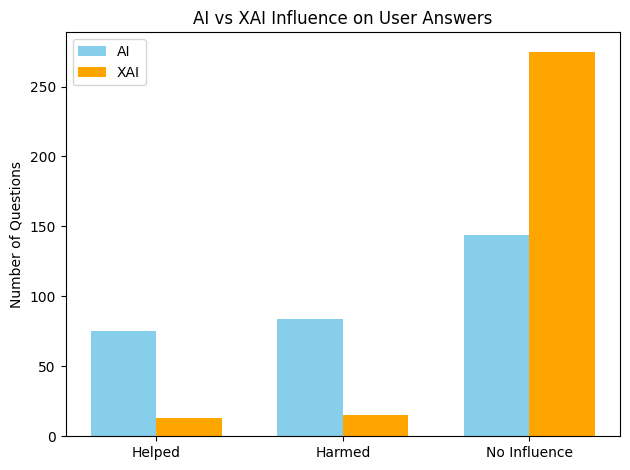

In [7]:
# Prepare data for plotting
categories = ['Helped', 'Harmed', 'No Influence']
ai_values = [totals['ai_helped_count'], totals['ai_harmed_count'], totals['ai_no_influence_count']]
xai_values = [totals['xai_helped_count'], totals['xai_harmed_count'], totals['xai_no_influence_count']]

x = np.arange(len(categories))  # the label locations
width = 0.35  # width of each bar

# Create plot
fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, ai_values, width, label='AI', color='skyblue')
rects2 = ax.bar(x + width/2, xai_values, width, label='XAI', color='orange')

# Labels and layout
ax.set_ylabel('Number of Questions')
ax.set_title('AI vs XAI Influence on User Answers')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.tight_layout()
plt.show()

# Check the confidence

In [8]:
def confidence_2_num(confidence):
    if pd.isna(confidence) or confidence == '-':
        return 0

    return float(confidence)
    
def confidence_test(users, users_logs):
    results = {}
    total_llm_qeustions = 0
    total_os_questions = 0
    total_llm_confidence = 0
    total_os_confidence = 0

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        questions_LLM = 0
        questions_OS = 0

        # os params
        confidence_before_ai_os = 0
        before_ai_stages_os = 0
        
        confidence_after_ai_os = 0
        after_ai_stages_os = 0
        
        confidence_after_xai_os = 0
        after_xai_stages_os = 0

        # llm params
        confidence_before_ai_llm = 0
        before_ai_stages_llm = 0
        
        confidence_after_ai_llm = 0
        after_ai_stages_llm = 0
        
        confidence_after_xai_llm = 0
        after_xai_stages_llm = 0
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']
            confidence_0 = row['face_0_BeforeAi']
            confidence_1 = row['face_1_AfterAi']
            confidence_2 = row['face_2_AfterXai']

            # Filter rows that contain question data
            if explanation_type in ('LLM', 'OS'):

                if explanation_type == "OS":
                    questions_OS += 1

                    confidence_before_ai_os, before_ai_stages_os = (
                        confidence_before_ai_os + confidence_0, 
                        before_ai_stages_os + 1
                    )
                    
                    (conf := confidence_2_num(confidence_1))
                    confidence_after_ai_os, after_ai_stages_os = (
                        confidence_after_ai_os + conf, 
                        after_ai_stages_os + (conf != 0)
                    )

                    (conf := confidence_2_num(confidence_2))
                    confidence_after_xai_os, after_xai_stages_os = (
                        confidence_after_xai_os + conf, 
                        after_xai_stages_os + (conf != 0)
                    )
                    
                    
                else:
                    questions_LLM += 1
                    confidence_before_ai_llm, before_ai_stages_llm = (
                        confidence_before_ai_llm + confidence_0, 
                        before_ai_stages_llm + 1
                    )
                    
                    (conf := confidence_2_num(confidence_1))
                    confidence_after_ai_llm, after_ai_stages_llm = (
                        confidence_after_ai_llm + conf, 
                        after_ai_stages_llm + (conf != 0)
                    )

                    (conf := confidence_2_num(confidence_2))
                    confidence_after_xai_llm, after_xai_stages_llm = (
                        confidence_after_xai_llm + conf, 
                        after_xai_stages_llm + (conf != 0)
                    )
                

        results[user] = {
            "questions_LLM": questions_LLM,
            "questions_OS": questions_OS,
            # saved in this format: (total confidence, total stages for this confidence)
            "confidence_before_ai_os": (confidence_before_ai_os, before_ai_stages_os), 
            "confidence_after_ai_os": (confidence_after_ai_os, after_ai_stages_os), 
            "confidence_after_xai_os": (confidence_after_xai_os, after_xai_stages_os),
            "confidence_before_ai_llm": (confidence_before_ai_llm, before_ai_stages_llm), 
            "confidence_after_ai_llm": (confidence_after_ai_llm, after_ai_stages_llm), 
            "confidence_after_xai_llm": (confidence_after_xai_llm, after_xai_stages_llm),
        }

    return results

In [9]:
confidence_results = confidence_test(users, df)

In [10]:
confidence_results

{'UID_Cm44VX12kN77eW40XE': {'questions_LLM': 6,
  'questions_OS': 5,
  'confidence_before_ai_os': (16.0, 5),
  'confidence_after_ai_os': (16.0, 4),
  'confidence_after_xai_os': (16.0, 4),
  'confidence_before_ai_llm': (19.0, 6),
  'confidence_after_ai_llm': (16.0, 4),
  'confidence_after_xai_llm': (16.0, 4)},
 'UID_Ze37Xr41oo26Tt92ZV': {'questions_LLM': 6,
  'questions_OS': 5,
  'confidence_before_ai_os': (20.0, 5),
  'confidence_after_ai_os': (17.0, 4),
  'confidence_after_xai_os': (17.0, 4),
  'confidence_before_ai_llm': (23.0, 6),
  'confidence_after_ai_llm': (18.0, 4),
  'confidence_after_xai_llm': (19.0, 4)},
 'UID_CC86nM66ZW38pf99WH': {'questions_LLM': 5,
  'questions_OS': 5,
  'confidence_before_ai_os': (13.0, 5),
  'confidence_after_ai_os': (13.0, 4),
  'confidence_after_xai_os': (13.0, 4),
  'confidence_before_ai_llm': (18.0, 5),
  'confidence_after_ai_llm': (16.0, 4),
  'confidence_after_xai_llm': (16.0, 4)},
 'UID_AL87Ek96Sq47GP20Gk': {'questions_LLM': 7,
  'questions_OS': 6

In [11]:
# Separate totals for tuple values and scalar ints
totals = {}

for stats in confidence_results.values():
    for key, value in stats.items():
        if isinstance(value, tuple):
            if key not in totals:
                totals[key] = (0.0, 0)
            a, b = totals[key]
            x, y = value
            totals[key] = (a + x, b + y)
        else:
            if key not in totals:
                totals[key] = 0
            totals[key] += value

print(totals)

{'questions_LLM': 157, 'questions_OS': 146, 'confidence_before_ai_os': (544.0, 146), 'confidence_after_ai_os': (378.0, 104), 'confidence_after_xai_os': (395.0, 104), 'confidence_before_ai_llm': (566.0, 157), 'confidence_after_ai_llm': (369.0, 103), 'confidence_after_xai_llm': (394.0, 103)}


In [12]:
# Prepare processed output
rows = []
rows.append({
    'Explanation type': 'LLM',
    'Mean confidence before ai': f"{(totals['confidence_before_ai_llm'][0] / totals['confidence_before_ai_llm'][1]):.1f}",
    'Mean confidence after ai': f"{(totals['confidence_after_ai_llm'][0] / totals['confidence_after_ai_llm'][1]):.1f}",
    'Mean confidence after xai': f"{(totals['confidence_after_xai_llm'][0] / totals['confidence_after_xai_llm'][1]):.1f}",
    '# Questions': totals['questions_LLM'],
})
rows.append({
    'Explanation type': 'OS',
    'Mean confidence before ai': f"{(totals['confidence_before_ai_os'][0] / totals['confidence_before_ai_os'][1]):.1f}",
    'Mean confidence after ai': f"{(totals['confidence_after_ai_os'][0] / totals['confidence_after_ai_os'][1]):.1f}",
    'Mean confidence after xai': f"{(totals['confidence_after_xai_os'][0] / totals['confidence_after_xai_os'][1]):.1f}",
    '# Questions': totals['questions_OS'],
})

df_result = pd.DataFrame(rows)
df_result

,Explanation type,Mean confidence before ai,Mean confidence after ai,Mean confidence after xai,# Questions
0,LLM,3.6,3.6,3.8,157
1,OS,3.7,3.6,3.8,146


# Check accuracy by personal details @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@

In [13]:
def get_users_details(df):
    users = {}
    
    for _, row in df.iterrows():
        
        ranodom_id = row['RandomTempUID']
    
        users[ranodom_id] = {
            "name": row['Name'],
            "age": row['Age'],
            "gender": row['Gender'],
            "ai_experince": row['AIExperienceYears'],
            "explanation_type_preffered": row['ExplanationTypePreference'],
            "details_explanation_preffered": row['DetailsInExplanationPreference'],
        }

    return users

In [14]:
users_details = get_users_details(df_experiment_details)

In [15]:
users_details

{'UID_Sp59WX69Ls96IJ56yH': {'name': 'Shachar Sagi',
  'age': 28,
  'gender': 'male',
  'ai_experince': '3-4',
  'explanation_type_preffered': 'textual',
  'details_explanation_preffered': 'brief'},
 'UID_bv13An42XI68xl08lQ': {'name': ' Aviv Weidenfeld',
  'age': 29,
  'gender': 'male',
  'ai_experince': '1-2',
  'explanation_type_preffered': 'visual',
  'details_explanation_preffered': 'brief'},
 'UID_zv91uL38jb94JM58Jd': {'name': 'Ben Eli',
  'age': 26,
  'gender': 'male',
  'ai_experince': '1-2',
  'explanation_type_preffered': 'visual',
  'details_explanation_preffered': 'brief'},
 'UID_ew60Nc39UF65Cn93Gi': {'name': 'Eden Barda',
  'age': 28,
  'gender': 'male',
  'ai_experince': '3-4',
  'explanation_type_preffered': 'textual',
  'details_explanation_preffered': 'detailed'},
 'UID_GC64QU46gM94GA17IQ': {'name': 'Nir Koren',
  'age': 28,
  'gender': 'male',
  'ai_experince': '3-4',
  'explanation_type_preffered': 'visual',
  'details_explanation_preffered': 'brief'},
 'UID_Gz29hR95Pg

In [16]:
def get_users_data(users_logs, group_id):
    users_data = users_logs[users_logs['param1'] == group_id]

    users_num = users_data['tuid'].unique()

    results = {}
    for user in users_num:

        user_rows = users_data[users_data['tuid'] == user]

        user_rows = user_rows.copy()  # Make an explicit copy to avoid chained assignment
        user_rows.loc[:, 'lInd_0_BeforeAi'] = pd.to_numeric(user_rows['lInd_0_BeforeAi'], errors='coerce')
        user_rows.loc[:, 'lInd_1_AfterAi'] = pd.to_numeric(user_rows['lInd_1_AfterAi'], errors='coerce')
        user_rows.loc[:, 'lInd_2_AfterXai'] = pd.to_numeric(user_rows['lInd_2_AfterXai'], errors='coerce')
        
        
        before_ai_correct_rows = user_rows[user_rows['trueShapeChoiceIndex'] == user_rows['lInd_0_BeforeAi']]
        before_ai_wrong_rows = user_rows[user_rows['trueShapeChoiceIndex'] != user_rows['lInd_0_BeforeAi']]
        
        after_ai_correct_rows = user_rows[
            ~pd.isna(user_rows['lInd_1_AfterAi']) &
            (user_rows['lInd_1_AfterAi'] != '-') &
            (user_rows['trueShapeChoiceIndex'] == user_rows['lInd_1_AfterAi'])
        ]
        
        after_ai_wrong_rows = user_rows[
            ~pd.isna(user_rows['lInd_1_AfterAi']) &
            (user_rows['lInd_1_AfterAi'] != '-') &
            (user_rows['trueShapeChoiceIndex'] != user_rows['lInd_1_AfterAi'])
        ]
    
        after_xai_correct_rows = user_rows[
            ~pd.isna(user_rows['lInd_2_AfterXai']) &
            (user_rows['lInd_2_AfterXai'] != '-') &
            (user_rows['trueShapeChoiceIndex'] == user_rows['lInd_2_AfterXai'])
        ]
        
        after_xai_wrong_rows = user_rows[
            ~pd.isna(user_rows['lInd_2_AfterXai']) &
            (user_rows['lInd_2_AfterXai'] != '-') &
            (user_rows['trueShapeChoiceIndex'] != user_rows['lInd_2_AfterXai'])
        ]
        
        results[user] = {
            'before_ai_correct_rows': len(before_ai_correct_rows),
            'before_ai_wrong_rows': len(before_ai_wrong_rows),
            'after_ai_correct_rows': len(after_ai_correct_rows),
            'after_ai_wrong_rows': len(after_ai_wrong_rows),
            'after_xai_correct_rows': len(after_xai_correct_rows),
            'after_xai_wrong_rows': len(after_xai_wrong_rows)
        } 

    return results

In [17]:
llm_data = get_users_data(df, 'LLM')
os_data = get_users_data(df, 'OS')
llm_data

{'UID_zv91uL38jb94JM58Jd': {'before_ai_correct_rows': 4,
  'before_ai_wrong_rows': 4,
  'after_ai_correct_rows': 2,
  'after_ai_wrong_rows': 2,
  'after_xai_correct_rows': 2,
  'after_xai_wrong_rows': 2},
 'UID_Sp59WX69Ls96IJ56yH': {'before_ai_correct_rows': 4,
  'before_ai_wrong_rows': 3,
  'after_ai_correct_rows': 2,
  'after_ai_wrong_rows': 2,
  'after_xai_correct_rows': 1,
  'after_xai_wrong_rows': 3},
 'UID_bv13An42XI68xl08lQ': {'before_ai_correct_rows': 3,
  'before_ai_wrong_rows': 3,
  'after_ai_correct_rows': 3,
  'after_ai_wrong_rows': 1,
  'after_xai_correct_rows': 3,
  'after_xai_wrong_rows': 1},
 'UID_ml46KH20Ef19wE69ad': {'before_ai_correct_rows': 2,
  'before_ai_wrong_rows': 4,
  'after_ai_correct_rows': 3,
  'after_ai_wrong_rows': 1,
  'after_xai_correct_rows': 3,
  'after_xai_wrong_rows': 1},
 'UID_ew60Nc39UF65Cn93Gi': {'before_ai_correct_rows': 1,
  'before_ai_wrong_rows': 4,
  'after_ai_correct_rows': 2,
  'after_ai_wrong_rows': 2,
  'after_xai_correct_rows': 2,
  'af

In [18]:
def get_success_per_group(group_data):
    before_ai_correct = 0
    before_ai_total = 0

    after_ai_correct = 0
    after_ai_total = 0

    after_xai_correct = 0
    after_xai_total = 0
    
    for user in group_data:
        before_ai_correct += group_data[user]['before_ai_correct_rows']
        before_ai_total += group_data[user]['before_ai_correct_rows'] + group_data[user]['before_ai_wrong_rows']
        
        after_ai_correct += group_data[user]['after_ai_correct_rows']
        after_ai_total += group_data[user]['after_ai_correct_rows'] + group_data[user]['after_ai_correct_rows']

        after_xai_correct += group_data[user]['after_xai_correct_rows']
        after_xai_total += group_data[user]['after_xai_correct_rows'] + group_data[user]['after_xai_wrong_rows']
    
    return before_ai_correct, before_ai_total, after_ai_correct, after_ai_total, after_xai_correct, after_xai_total
    
def get_table_results(groups):
    rows = []
    for group_id, data in groups.items():
    
        before_ai_correct, before_ai_total, after_ai_correct, after_ai_total, after_xai_correct, after_xai_total = get_success_per_group(data)
    
        row = {
            'Group': group_id,
            'Before AI correct answers': f"{before_ai_correct}/{before_ai_total}",
            'After AI correct answers': f"{after_ai_correct}/{after_ai_total}",
            'After XAI correct answers': f"{after_xai_correct}/{after_xai_total}",
        }
        rows.append(row)
    
    df_result = pd.DataFrame(rows)
    return df_result

### Check what was the accuracy in the gender groups

In [19]:
def divide_groups_by_gender(users_results, users_details):
    women = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('gender') == 'female'
    }
    men = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('gender') == 'male'
    }
    return women, men

In [20]:
women_llm, men_llm = divide_groups_by_gender(llm_data, users_details)
women_os, men_os = divide_groups_by_gender(os_data, users_details)

In [21]:
gender_table = get_table_results(groups = {
    'Female - LLM part': women_llm,
    'Male - LLM part': men_llm,
    'Female - OS part': women_os,
    'Male - OS part': men_os
})
gender_table

,Group,Before AI correct answers,After AI correct answers,After XAI correct answers
0,Female - LLM part,23/52,19/38,17/30
1,Male - LLM part,41/105,39/78,34/73
2,Female - OS part,12/44,15/30,15/29
3,Male - OS part,36/102,30/60,35/75


### Check what was the accuracy in the ai experience groups

In [72]:
def divide_groups_by_ai_experience(users_results, users_details):
    ai_0_1 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '0-1'
    }
    ai_1_2 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '1-2'
    }
    ai_3_4 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '3-4'
    }
    ai_5 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '5'
    }
    return ai_0_1, ai_1_2, ai_3_4, ai_5

In [74]:
ai_0_1_llm, ai_1_2_llm, ai_3_4_llm, ai_5_llm = divide_groups_by_ai_experience(llm_data, users_details)
ai_0_1_os, ai_1_2_os, ai_3_4_os, ai_5_os = divide_groups_by_ai_experience(os_data, users_details)

In [75]:
ai_experience_table = get_table_results(groups = {
    'LLM: AI Experience: 0-1 Years': ai_0_1_llm,
    'LLM: AI Experience: 1-2 Years': ai_1_2_llm,
    'LLM: AI Experience: 3–4 Years': ai_3_4_llm,
    'LLM: AI Experience: 5+ Years': ai_5_llm,
    'OS: AI Experience: 0-1 Years': ai_0_1_os,
    'OS: AI Experience: 1-2 Years': ai_1_2_os,
    'OS: AI Experience: 3–4 Years': ai_3_4_os,
    'OS: AI Experience: 5+ Years': ai_5_os,
})
ai_experience_table

,Group,Before AI correct answers,After AI correct answers,After XAI correct answers
0,LLM: AI Experience: 0-1 Years,12/28,12/24,11/19
1,LLM: AI Experience: 1-2 Years,44/108,38/76,34/68
2,LLM: AI Experience: 3–4 Years,8/21,8/16,6/16
3,LLM: AI Experience: 5+ Years,0/0,0/0,0/0
4,OS: AI Experience: 0-1 Years,7/30,8/16,10/22
5,OS: AI Experience: 1-2 Years,28/91,28/56,32/66
6,OS: AI Experience: 3–4 Years,13/25,9/18,8/16
7,OS: AI Experience: 5+ Years,0/0,0/0,0/0


## Check what was the accuracy in the ExplanationTypePreference groups

In [22]:
def divide_groups_by_explanation_type(users_results, users_details):
    visual = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('explanation_type_preffered') == 'visual'
    }
    textual = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('explanation_type_preffered') == 'textual'
    }
    return visual, textual

In [23]:
visual_llm, textual_llm = divide_groups_by_explanation_type(llm_data, users_details)
visual_os, textual_os = divide_groups_by_explanation_type(os_data, users_details)

In [24]:
explnation_type_table = get_table_results(groups = {
    'Visual explanation preffered (LLM part)': visual_llm,
    'Visual explanation preffered (OS part)': visual_os,

    'Textual explanation preffered (LLM part)': textual_llm,
    'Textual explanation preffered (OS part)': textual_os,
})
explnation_type_table

,Group,Before AI correct answers,After AI correct answers,After XAI correct answers
0,Visual explanation preffered (LLM part),45/108,40/80,35/67
1,Visual explanation preffered (OS part),31/92,27/54,30/65
2,Textual explanation preffered (LLM part),19/49,18/36,16/36
3,Textual explanation preffered (OS part),17/54,18/36,20/39


### Check what was the accuracy in the DetailsInExplanationPreference groups

In [25]:
def divide_groups_by_details_explanation(users_results, users_details):
    detailed = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('details_explanation_preffered') == 'detailed'
    }
    brief = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('details_explanation_preffered') == 'brief'
    }
    return detailed, brief

In [26]:
detailed_llm, brief_llm = divide_groups_by_details_explanation(llm_data, users_details)
detailed_os, brief_os = divide_groups_by_details_explanation(os_data, users_details)

In [27]:
explnation_details_table = get_table_results(groups = {
    'Detailed explanation preffered (LLM part)': detailed_llm,
    'Detailed explanation preffered (OS part)': detailed_os,

    'Brief explanation preffered (LLM part)': brief_llm,
    'Brief explanation preffered (OS part)': brief_os,
})
explnation_details_table

,Group,Before AI correct answers,After AI correct answers,After XAI correct answers
0,Detailed explanation preffered (LLM part),19/38,12/24,10/23
1,Detailed explanation preffered (OS part),15/36,8/16,9/20
2,Brief explanation preffered (LLM part),45/119,46/92,41/80
3,Brief explanation preffered (OS part),33/110,37/74,41/84


### Check what was the accuracy in the age groups

In [29]:
def divide_groups_by_age(users_results, users_details):
    age_25_minus = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('age') <= 25
    }
    age_25_plus = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('age') > 25
    }
    return age_25_minus, age_25_plus

In [30]:
age_25_minus_llm, age_25_plus_llm = divide_groups_by_age(llm_data, users_details)
age_25_minus_os, age_25_plus_os = divide_groups_by_age(os_data, users_details)

In [31]:
age_table = get_table_results(groups = {
    'Age <= 25 (LLM part)': age_25_minus_llm,
    'Age <= 25 (OS part)': age_25_minus_os,

    'Age > 25 (LLM part)': age_25_plus_llm,
    'Age > 25 (OS part)': age_25_plus_os,
})
age_table

,Group,Before AI correct answers,After AI correct answers,After XAI correct answers
0,Age <= 25 (LLM part),24/56,20/40,18/35
1,Age <= 25 (OS part),13/48,16/32,18/35
2,Age > 25 (LLM part),40/101,38/76,33/68
3,Age > 25 (OS part),35/98,29/58,32/69


## Check how the first block of explanation affected the user accuracy in the second block

In [8]:
def analysis_block_affect(users, users_logs):
    results = {}

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]

        correct_count = 0
        block2_question_amount = 0

        first_explanation_block = (next(user_data.iterrows())[1])['param1']
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            explanation_type = row['param1']

            # Filter the rows of explanaion second block 
            if pd.notna(explanation_type) and explanation_type != first_explanation_block:
                block2_question_amount += 1
                
                if before_ai == true_choice:
                    correct_count += 1

            results[user] = {
                "correct": correct_count,
                "block2_question_amount": block2_question_amount,
                "first_explanation": first_explanation_block, 
                "success": f"{(correct_count / block2_question_amount * 100):.1f}%" if block2_question_amount > 0 else "N/A"
            }
    return results            
                

In [9]:
block_results = analysis_block_affect(users, df)

In [10]:
block_results

{'UID_iQ88Eg36pD60mG02Fi': {'correct': 3,
  'block2_question_amount': 6,
  'first_explanation': 'OS',
  'success': '50.0%'},
 'UID_cZ66ys08Pp83MP90Yn': {'correct': 1,
  'block2_question_amount': 3,
  'first_explanation': 'LLM',
  'success': '33.3%'},
 'UID_NB30mT87Ki02rP44pa': {'correct': 2,
  'block2_question_amount': 3,
  'first_explanation': 'LLM',
  'success': '66.7%'},
 'UID_zv91uL38jb94JM58Jd': {'correct': 1,
  'block2_question_amount': 4,
  'first_explanation': 'LLM',
  'success': '25.0%'},
 'UID_By02ns11Lv64xM09IR': {'correct': 0,
  'block2_question_amount': 0,
  'first_explanation': 'OS',
  'success': 'N/A'},
 'UID_bv13An42XI68xl08lQ': {'correct': 2,
  'block2_question_amount': 6,
  'first_explanation': 'LLM',
  'success': '33.3%'},
 'UID_fQ41dE04fP47pK90FA': {'correct': 3,
  'block2_question_amount': 6,
  'first_explanation': 'LLM',
  'success': '50.0%'},
 'UID_xb17Ox51pV61Cj23td': {'correct': 2,
  'block2_question_amount': 6,
  'first_explanation': 'LLM',
  'success': '33.3%

In [11]:
# Initialize containers
llm_successes = [] # llm affected the success in block 2
os_successes = [] # os affected the success in block 2

# Collect success rates
for user_data in block_results.values():
    success_str = user_data['success']
    
    if success_str != "N/A":  # Ignore entries with no valid data
        success = float(success_str.strip('%'))
        if user_data['first_explanation'] == 'LLM':
            llm_successes.append(success)
        elif user_data['first_explanation'] == 'OS':
            os_successes.append(success)

# Compute means
llm_mean = sum(llm_successes) / len(llm_successes) if llm_successes else 0
os_mean = sum(os_successes) / len(os_successes) if os_successes else 0

print(f"LLM Mean Success Rate: {llm_mean:.1f}%")
print(f"OS Mean Success Rate: {os_mean:.1f}%")

LLM Mean Success Rate: 35.1%
OS Mean Success Rate: 30.3%


## Check the post hoc questions results

In [12]:
def analysis_post_hoc_explanation(users, users_logs):
    llm_qs_sum = {'q1': 0, 'q2': 0, 'q3': 0}
    os_qs_sum = {'q1': 0, 'q2': 0, 'q3': 0}
    
    llm_qs_count = {'q1': 0, 'q2': 0, 'q3': 0}
    os_qs_count = {'q1': 0, 'q2': 0, 'q3': 0}

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]

        for _, row in user_data.iterrows():
            object_log_name = row['objectLogName']
            confidence_level = row['faceSelected']

            if object_log_name.endswith('_SubmitRatingBtn'):
                for q_type, qs_sum, qs_count in [('LLM', llm_qs_sum, llm_qs_count), ('OS', os_qs_sum, os_qs_count)]:
                    for i in range(1, 4):
                        key = f'q{i}'
                        if f'{q_type}_question_{i}' in object_log_name:
                            qs_sum[key] += confidence_level
                            qs_count[key] += 1
                            break

    return {
        'llm': {'sum': llm_qs_sum, 'count': llm_qs_count},
        'os': {'sum': os_qs_sum, 'count': os_qs_count}
    }

In [13]:
results = analysis_post_hoc_explanation(users, df)

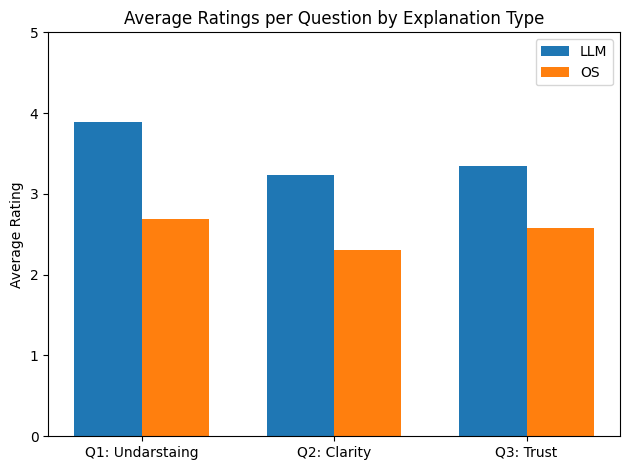

In [14]:
# Calculate averages
llm_means = [results['llm']['sum'][f'q{i}'] / results['llm']['count'][f'q{i}'] if results['llm']['count'][f'q{i}'] else 0 for i in range(1, 4)]
os_means = [results['os']['sum'][f'q{i}'] / results['os']['count'][f'q{i}'] if results['os']['count'][f'q{i}'] else 0 for i in range(1, 4)]

# Create bar plot
questions = ['Q1: Undarstaing', 'Q2: Clarity', 'Q3: Trust']
x = range(len(questions))
width = 0.35

fig, ax = plt.subplots()
ax.bar([i - width/2 for i in x], llm_means, width, label='LLM')
ax.bar([i + width/2 for i in x], os_means, width, label='OS')

ax.set_ylabel('Average Rating')
ax.set_title('Average Ratings per Question by Explanation Type')
ax.set_xticks(x)
ax.set_xticklabels(questions)
ax.set_ylim(0, 5)
ax.legend()

plt.tight_layout()
plt.show()

# Check how many users were right before the prediction

In [15]:
def right_before_ai(users, users_logs):
    questions_num = 0
    right_predictions = 0
    wrong_predictions = 0

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if explanation_type in ('LLM', 'OS'):
                if before_ai == true_choice:
                    questions_num += 1
                    
                    if true_choice == pred_choice:
                        right_predictions += 1
                    else:
                        wrong_predictions += 1

    return questions_num, right_predictions, wrong_predictions

In [16]:
questions_num, right_predictions, wrong_predictions = right_before_ai(users, df)

In [17]:
questions_num, right_predictions, wrong_predictions

(112, 77, 35)

# Check how many question with pred=true

In [18]:
def check_llm_os_questions(users, users_logs):
    llm_pred_true_match_count = 0
    os_pred_true_match_count = 0
    
    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if explanation_type in ('LLM', 'OS'):
                if pred_choice == true_choice:
                    
                    if explanation_type == "OS":
                        os_pred_true_match_count += 1
                    else:
                        llm_pred_true_match_count += 1

    return os_pred_true_match_count, llm_pred_true_match_count

In [19]:
os, llm = check_llm_os_questions(users, df)

In [20]:
os, llm

(91, 95)

# Check what was the success % in the second block to those who xai helped them

In [21]:
results = analysis_test_results(users, df)

In [22]:
block_results = analysis_block_affect(users, df)

In [23]:
success_rate = 0
users_num = 0

for user in results:
    if results[user]['xai_helped_count'] > 0:
        users_num += 1

        success_str = block_results[user]['success']
        if success_str != "N/A":  # Ignore entries with no valid data
            success = float(success_str.strip('%'))
            success_rate += success

In [24]:
success_rate, users_num

(410.0, 11)

In [25]:
success_rate/users_num

37.27272727272727

# Testing the percentage of correct answers (before AI) in the first block compared to the second block

In [26]:
def analysis_block_success(users, users_logs):
    results = {}

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]

        llm_correct_count = 0
        os_correct_count = 0
        os_questions = 0
        llm_questions = 0
        
        first_explanation_block = (next(user_data.iterrows())[1])['param1']
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            explanation_type = row['param1']

            # Filter the rows of explanaion second block 
            if pd.notna(explanation_type):
                if explanation_type == "LLM":
                    llm_questions += 1
                    
                    if before_ai == true_choice:
                        llm_correct_count += 1
                else:
                    os_questions += 1

                    if before_ai == true_choice:
                        os_correct_count += 1
                    

        results[user] = {
            "first_explanation": first_explanation_block,
            "llm_correct": llm_correct_count,
            "os_correct": os_correct_count,
            "llm_questions": llm_questions, 
            "os_questions": os_questions,
            "success_os": f"{(os_correct_count / os_questions * 100):.1f}%" if os_questions > 0 else "N/A",
            "success_llm": f"{(llm_correct_count / llm_questions * 100):.1f}%" if llm_questions > 0 else "N/A"
        }
    return results            

In [27]:
results = analysis_block_success(users, df)
results

{'UID_iQ88Eg36pD60mG02Fi': {'first_explanation': 'OS',
  'llm_correct': 3,
  'os_correct': 0,
  'llm_questions': 6,
  'os_questions': 4,
  'success_os': '0.0%',
  'success_llm': '50.0%'},
 'UID_cZ66ys08Pp83MP90Yn': {'first_explanation': 'LLM',
  'llm_correct': 5,
  'os_correct': 1,
  'llm_questions': 8,
  'os_questions': 3,
  'success_os': '33.3%',
  'success_llm': '62.5%'},
 'UID_NB30mT87Ki02rP44pa': {'first_explanation': 'LLM',
  'llm_correct': 4,
  'os_correct': 2,
  'llm_questions': 7,
  'os_questions': 3,
  'success_os': '66.7%',
  'success_llm': '57.1%'},
 'UID_zv91uL38jb94JM58Jd': {'first_explanation': 'LLM',
  'llm_correct': 4,
  'os_correct': 1,
  'llm_questions': 8,
  'os_questions': 4,
  'success_os': '25.0%',
  'success_llm': '50.0%'},
 'UID_By02ns11Lv64xM09IR': {'first_explanation': 'OS',
  'llm_correct': 0,
  'os_correct': 1,
  'llm_questions': 0,
  'os_questions': 3,
  'success_os': '33.3%',
  'success_llm': 'N/A'},
 'UID_bv13An42XI68xl08lQ': {'first_explanation': 'LLM',

In [28]:
llm_os_results = {
    "llm":{
        'llm_correct': 0,
        'os_correct': 0,
        'llm_questions': 0,
        'os_questions': 0,
    },
    "os": {
        'llm_correct': 0,
        'os_correct': 0,
        'llm_questions': 0,
        'os_questions': 0,
    }
}
os = 0
llm = 0
for user in results:
    explanation_type = results[user]['first_explanation'].lower()
    
    llm_os_results[explanation_type] = {
        'llm_correct': llm_os_results[explanation_type]['llm_correct']+results[user]['llm_correct'],
        'os_correct': llm_os_results[explanation_type]['os_correct']+results[user]['os_correct'],
        'llm_questions': llm_os_results[explanation_type]['llm_questions']+results[user]['llm_questions'],
        'os_questions': llm_os_results[explanation_type]['os_questions']+results[user]['os_questions'],
    }

In [29]:
llm_os_results

{'llm': {'llm_correct': 53,
  'os_correct': 41,
  'llm_questions': 123,
  'os_questions': 111},
 'os': {'llm_correct': 11,
  'os_correct': 7,
  'llm_questions': 34,
  'os_questions': 35}}

In [37]:
# when llm first explanation 
llm_first = (llm_os_results['llm']['llm_correct']/llm_os_results['llm']['llm_questions'] * 100) 
os_second = (llm_os_results['llm']['os_correct']/llm_os_results['llm']['os_questions'] * 100) 

# when os first explanation
os_first = (llm_os_results['os']['os_correct']/llm_os_results['os']['os_questions'] * 100) 
llm_second = (llm_os_results['os']['llm_correct']/llm_os_results['os']['llm_questions'] * 100)

print("When LLM was presented first:")
print(f"Correct answeres(before ai = true) in the LLM part:{llm_first:.1f}% and in the OS part: {os_second:.1f}%\n")
print("When OS was presented first:")
print(f"Correct answeres(before ai = true) in the OS part:{os_first:.1f}% and in the LLM part: {llm_second:.1f}%")

When LLM was presented first:
Correct answeres(before ai = true) in the LLM part:43.1% and in the OS part: 36.9%

When OS was presented first:
Correct answeres(before ai = true) in the OS part:20.0% and in the LLM part: 32.4%


### Calc total success in each explanation block

In [39]:
print(f"Success rate in llm part:{(llm_first+llm_second)/2:.1f}")
print(f"Success rate in os part:{(os_first+os_second)/2:.1f}")

Success rate in llm part:37.7
Success rate in os part:28.5


# Check: Are some Raven questions consistently helped by XAI while others aren't?
## How: Group by question_id, average accuracy before/after XAI.

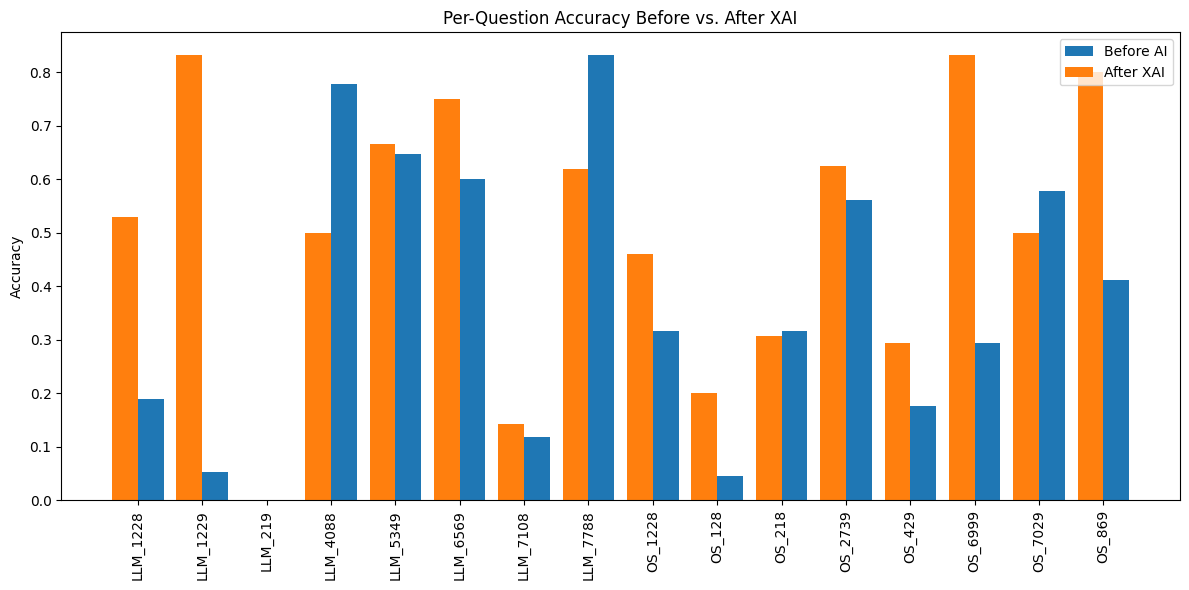

In [149]:
plt.figure(figsize=(12, 6))
x = range(len(question_effectiveness))
plt.bar(x, question_effectiveness['accuracy_before_ai'], label='Before AI', width=0.4, align='edge')
plt.bar(x, question_effectiveness['accuracy_after_xai'], label='After XAI', width=-0.4, align='edge')
plt.xticks(x, question_effectiveness['question_id'], rotation=90)
plt.ylabel('Accuracy')
plt.title('Per-Question Accuracy Before vs. After XAI')
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
import re
def analyze_by_quesion(users, users_logs):
    results = {}

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            question_num = row['objectLogName']
            
            explanation_type = row['param1']

            # Filter rows that contain question data
            match = re.search(r'(LLM|OS)_\d+', row['objectLogName'])
            if not match:
                continue  # skip non-question rows
            question_id = match.group(0)
                
            # Initialize entry if not present
            if question_id not in results:
                results[question_id] = {
                    'correct_before_ai': 0,
                    'before_ai_responses': 0,
                    'correct_after_ai': 0,
                    'after_ai_responses': 0,
                    'correct_after_xai': 0,
                    'after_xai_responses': 0
                }

            results[question_id]['before_ai_responses'] += 1
            if after_ai != None:
                results[question_id]['after_ai_responses'] += 1
            if after_xai != None:
                results[question_id]['after_xai_responses'] += 1
            
            # Increment correctness counters
            if before_ai == true_choice:
                results[question_id]['correct_before_ai'] += 1
            if after_ai == true_choice:
                results[question_id]['correct_after_ai'] += 1
            if after_xai == true_choice:
                results[question_id]['correct_after_xai'] += 1

    return results

In [68]:
data = analyze_by_quesion(users, df)
data

{'LLM_7108': {'correct_before_ai': 2,
  'before_ai_responses': 17,
  'correct_after_ai': 3,
  'after_ai_responses': 14,
  'correct_after_xai': 2,
  'after_xai_responses': 14},
 'LLM_219': {'correct_before_ai': 0,
  'before_ai_responses': 21,
  'correct_after_ai': 0,
  'after_ai_responses': 15,
  'correct_after_xai': 0,
  'after_xai_responses': 15},
 'LLM_7788': {'correct_before_ai': 20,
  'before_ai_responses': 24,
  'correct_after_ai': 14,
  'after_ai_responses': 21,
  'correct_after_xai': 13,
  'after_xai_responses': 21},
 'LLM_6569': {'correct_before_ai': 12,
  'before_ai_responses': 20,
  'correct_after_ai': 6,
  'after_ai_responses': 8,
  'correct_after_xai': 6,
  'after_xai_responses': 8},
 'LLM_1228': {'correct_before_ai': 4,
  'before_ai_responses': 21,
  'correct_after_ai': 11,
  'after_ai_responses': 17,
  'correct_after_xai': 9,
  'after_xai_responses': 17},
 'OS_7029': {'correct_before_ai': 11,
  'before_ai_responses': 19,
  'correct_after_ai': 4,
  'after_ai_responses': 8,

In [69]:
questions = {
    "OS_1228": {
        "category": "center_single",
        "prediction": True,
    },
    "OS_218": {
        "category": "in_center_single",
        "prediction": True,
    },
    "LLM_1229": {
        "category": "in_center_single",
        "prediction": True,
    },
    "LLM_219": {
        "category": "in_center_single",
        "prediction": False,
    },
    "OS_128": {
        "category": "left_center_single",
        "prediction": False,
    },
    "LLM_6569": {
        "category": "left_center_single",
        "prediction": True,
    },
    "LLM_7108": {
        "category": "left_center_single",
        "prediction": False,
    },
    "LLM_4088": {
        "category": "distribute_nine",
        "prediction": True,
    },
    "LLM_5349": {
        "category": "distribute_nine",
        "prediction": True,
    },
    "LLM_7788": {
        "category": "distribute_nine",
        "prediction": False,
    },
    "OS_869": {
        "category": "in_distribute_four",
        "prediction": True,
    },
    "OS_6999": {
        "category": "in_distribute_four",
        "prediction": True,
    },
    "OS_7029": {
        "category": "in_distribute_four",
        "prediction": True,
    },
    "OS_2739": {
        "category": "in_distribute_four",
        "prediction": False,
    },
    "OS_429": {
        "category": "up_center",
        "prediction": False,
    },
    "LLM_1228": {
        "category": "up_center",
        "prediction": True,
    },
}

In [70]:
# Prepare processed output
rows = []
for q_id, stats in data.items():
    row = {
        'question_id': q_id,
        "model_prediction_correct": questions[q_id]["prediction"], 
        'accuracy_before_ai': stats['correct_before_ai'] / stats['before_ai_responses'] if stats['before_ai_responses'] > 0 else None,
        'accuracy_after_ai': stats['correct_after_ai'] / stats['after_ai_responses'] if stats['after_ai_responses'] > 0 else None,
        'accuracy_after_xai': stats['correct_after_xai'] / stats['after_xai_responses'] if stats['after_xai_responses'] > 0 else None,
        'correct_before_ai': f"{stats['correct_before_ai']}/{stats['before_ai_responses']}",
        'correct_after_ai': f"{stats['correct_after_ai']}/{stats['after_ai_responses']}",
        'correct_after_xai': f"{stats['correct_after_xai']}/{stats['after_xai_responses']}"
    }
    rows.append(row)

df_result = pd.DataFrame(rows)
df_result

,question_id,model_prediction_correct,accuracy_before_ai,accuracy_after_ai,accuracy_after_xai,correct_before_ai,correct_after_ai,correct_after_xai
0,LLM_7108,False,0.117647,0.214286,0.142857,2/17,3/14,2/14
1,LLM_219,False,0.000000,0.000000,0.000000,0/21,0/15,0/15
2,LLM_7788,False,0.833333,0.666667,0.619048,20/24,14/21,13/21
3,LLM_6569,True,0.600000,0.750000,0.750000,12/20,6/8,6/8
4,LLM_1228,True,0.190476,0.647059,0.529412,4/21,11/17,9/17
5,OS_7029,True,0.578947,0.500000,0.500000,11/19,4/8,4/8
6,OS_2739,False,0.562500,0.562500,0.625000,9/16,9/16,10/16
7,OS_869,True,0.411765,0.800000,0.800000,7/17,8/10,8/10
8,OS_218,True,0.315789,0.384615,0.307692,6/19,5/13,4/13
9,OS_1228,True,0.315789,0.230769,0.461538,6/19,3/13,6/13


## Graphs

## 4 AB

In [6]:
def check_accuracy_acording_to_ai(users, users_logs):
    users_test_results = {
        "LLM": {
            "before_ai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "after_ai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "after_xai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "total_pred_correct_questions": 0,
            "total_pred_incorrect_questions": 0,
        },
        "OS": {
            "before_ai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "after_ai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "after_xai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "total_pred_correct_questions": 0,
            "total_pred_incorrect_questions": 0,
        }
    }

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if explanation_type in ("LLM", "OS"):

                # questions counter
                if pred_choice == true_choice:
                    users_test_results[explanation_type]["total_pred_correct_questions"] += 1
                else:
                    users_test_results[explanation_type]["total_pred_incorrect_questions"] += 1

                
                if pd.notna(before_ai) and after_ai == None and after_xai == None:
                    if before_ai == true_choice:
                        users_test_results[explanation_type]["before_ai"]["correct_answers"] += 1
                        
                        if pred_choice == true_choice:
                            users_test_results[explanation_type]["before_ai"]["correct_pred_questions"] += 1
                        else:
                            users_test_results[explanation_type]["before_ai"]["incorrect_pred_questions"] += 1
                        
                    users_test_results[explanation_type]["before_ai"]["questions"] += 1
                        
                elif pd.notna(before_ai) and pd.notna(after_ai) and pd.notna(after_xai):
                    users_test_results[explanation_type]["before_ai"]["questions"] += 1
                    users_test_results[explanation_type]["after_ai"]["questions"] += 1
                    users_test_results[explanation_type]["after_xai"]["questions"] += 1
                    
                    if before_ai == true_choice:
                        users_test_results[explanation_type]["before_ai"]["correct_answers"] += 1
                        category = "correct_pred_questions" if (pred_choice == true_choice) else "incorrect_pred_questions"
                        users_test_results[explanation_type]["before_ai"][category] += 1
                    if after_ai == true_choice:
                        users_test_results[explanation_type]["after_ai"]["correct_answers"] += 1
                        category = "correct_pred_questions" if (pred_choice == true_choice) else "incorrect_pred_questions"
                        users_test_results[explanation_type]["after_ai"][category] += 1
                    if after_xai == true_choice:
                        users_test_results[explanation_type]["after_xai"]["correct_answers"] += 1
                        category = "correct_pred_questions" if (pred_choice == true_choice) else "incorrect_pred_questions"
                        users_test_results[explanation_type]["after_xai"][category] += 1
    return users_test_results

In [9]:
users = set(df['tuid'])
success_rate = check_accuracy_acording_to_ai(users, df)

In [10]:
success_rate

{'LLM': {'before_ai': {'correct_answers': 64,
   'questions': 157,
   'correct_pred_questions': 42,
   'incorrect_pred_questions': 22},
  'after_ai': {'correct_answers': 58,
   'questions': 103,
   'correct_pred_questions': 41,
   'incorrect_pred_questions': 17},
  'after_xai': {'correct_answers': 51,
   'questions': 103,
   'correct_pred_questions': 36,
   'incorrect_pred_questions': 15},
  'total_pred_correct_questions': 95,
  'total_pred_incorrect_questions': 62},
 'OS': {'before_ai': {'correct_answers': 48,
   'questions': 146,
   'correct_pred_questions': 35,
   'incorrect_pred_questions': 13},
  'after_ai': {'correct_answers': 45,
   'questions': 104,
   'correct_pred_questions': 29,
   'incorrect_pred_questions': 16},
  'after_xai': {'correct_answers': 50,
   'questions': 104,
   'correct_pred_questions': 32,
   'incorrect_pred_questions': 18},
  'total_pred_correct_questions': 91,
  'total_pred_incorrect_questions': 55}}

## 5

In [12]:
def check_accuracy_acording_to_ai_prediction(users, users_logs):
    users_test_results = {
        "LLM": {
            "after_ai": {
                "matched_answers": 0,
                "questions": 0,
            },
            "after_xai": {
                "matched_answers": 0,
                "questions": 0,
            },
        },
        "OS": {
            "after_ai": {
                "matched_answers": 0,
                "questions": 0,
            },
            "after_xai": {
                "matched_answers": 0,
                "questions": 0,
            },
        }
    }

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if explanation_type in ("LLM", "OS"):        
                if pd.notna(before_ai) and pd.notna(after_ai) and pd.notna(after_xai):
                    users_test_results[explanation_type]["after_ai"]["questions"] += 1
                    users_test_results[explanation_type]["after_xai"]["questions"] += 1
                    
                    if after_ai == pred_choice:
                        users_test_results[explanation_type]["after_ai"]["matched_answers"] += 1
                    if after_xai == pred_choice:
                        users_test_results[explanation_type]["after_xai"]["matched_answers"] += 1
    return users_test_results

In [13]:
accuracy_by_model_prediction = check_accuracy_acording_to_ai_prediction(users, df)

In [14]:
accuracy_by_model_prediction

{'LLM': {'after_ai': {'matched_answers': 55, 'questions': 103},
  'after_xai': {'matched_answers': 53, 'questions': 103}},
 'OS': {'after_ai': {'matched_answers': 40, 'questions': 104},
  'after_xai': {'matched_answers': 47, 'questions': 104}}}

# 6

In [18]:
def extract_question_num(s):
    last_parts = s.split('_')[-2:]
    if last_parts[-1].isdigit():
        result = last_parts[-1]
    else:
        result = "_".join(last_parts)
    return result

def check_questions_accuracy(users, users_logs):
    questions = {}

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            question = extract_question_num(row['blockId'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']
            is_correct_prediction = row['isCorrectPrediction']

            # Filter rows that contain question data
            if explanation_type in ("LLM", "OS"): 
                if question not in questions:
                    questions[question] = {
                        "correct_answers": 0,
                        "question_appearances": 0,
                        "is_correct_prediction": is_correct_prediction,
                        "explanation": explanation_type
                    }
                if before_ai == true_choice:
                    questions[question]["correct_answers"] += 1

                questions[question]["question_appearances"] += 1
                
    return questions

In [19]:
questions = check_questions_accuracy(users, df)

In [20]:
questions

{'2739': {'correct_answers': 9,
  'question_appearances': 16,
  'is_correct_prediction': 'no',
  'explanation': 'OS'},
 '429': {'correct_answers': 3,
  'question_appearances': 17,
  'is_correct_prediction': 'no',
  'explanation': 'OS'},
 '6999': {'correct_answers': 5,
  'question_appearances': 17,
  'is_correct_prediction': 'yes',
  'explanation': 'OS'},
 '128': {'correct_answers': 1,
  'question_appearances': 22,
  'is_correct_prediction': 'no',
  'explanation': 'OS'},
 '5349': {'correct_answers': 11,
  'question_appearances': 17,
  'is_correct_prediction': 'yes',
  'explanation': 'LLM'},
 '4088': {'correct_answers': 14,
  'question_appearances': 18,
  'is_correct_prediction': 'yes',
  'explanation': 'LLM'},
 '6569': {'correct_answers': 12,
  'question_appearances': 20,
  'is_correct_prediction': 'yes',
  'explanation': 'LLM'},
 '7788': {'correct_answers': 20,
  'question_appearances': 24,
  'is_correct_prediction': 'no',
  'explanation': 'LLM'},
 '1229': {'correct_answers': 1,
  'que

# 7

In [50]:
def check_post_questions_affect(users, users_logs):
    results = {
        "LLM": {"q_1": {}, "q_2": {}, "q_3": {}},
        "OS": {"q_1": {}, "q_2": {}, "q_3": {}}
    }

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            block_id = row['blockId']
            rate = convert_2_int(row['faceSelected'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if pd.isna(explanation_type):
                
                # Get the question number at the end
                number = block_id.split('_')[-1]
                
                # Get the explanation type
                explanation = block_id.split('_')[4]

                if results[explanation][f"q_{number}"] == {}:
                    results[explanation][f"q_{number}"] = {"1": 0, "2": 0, "3": 0, "4": 0, "5": 0}

                results[explanation][f"q_{number}"][str(rate)] += 1
                
    return results

In [51]:
post_questions_rate = check_post_questions_affect(users, df)

In [52]:
post_questions_rate

{'LLM': {'q_1': {'1': 0, '2': 1, '3': 7, '4': 12, '5': 6},
  'q_2': {'1': 2, '2': 6, '3': 4, '4': 12, '5': 2},
  'q_3': {'1': 3, '2': 3, '3': 5, '4': 12, '5': 3}},
 'OS': {'q_1': {'1': 6, '2': 5, '3': 9, '4': 3, '5': 3},
  'q_2': {'1': 8, '2': 8, '3': 6, '4': 2, '5': 2},
  'q_3': {'1': 3, '2': 11, '3': 7, '4': 4, '5': 1}}}